## Reading CSV & First-Look Profiling


In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(r'Data\Merged\Merged.csv')
print(df.shape) # rows × cols

(409836, 10)


In [337]:
df.head() # first 5 rows

,date,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall
0,1984-01-01,17.26,52.93,101.60,2.04,19.4,15.53,6.69,Barisal,0.0
1,1984-01-02,18.29,52.62,101.50,1.48,0.0,15.13,7.51,Barisal,0.0
2,1984-01-03,19.46,59.20,101.65,1.95,68.8,9.31,10.77,Barisal,0.0
3,1984-01-04,19.43,59.06,101.67,2.10,0.0,15.30,10.55,Barisal,0.0
4,1984-01-05,18.74,59.80,101.57,1.99,0.0,15.42,10.07,Barisal,0.0


In [338]:
df.tail(3) # last 3 rows

,date,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall
409833,2016-12-29,20.65,86.11,100.52,0.64,5.48,17.72,18.18,Teknaf,0.0
409834,2016-12-30,19.99,89.56,100.58,0.71,5.75,17.59,18.40,Teknaf,0.0
409835,2016-12-31,19.58,89.10,100.52,0.74,7.66,17.64,18.13,Teknaf,0.0


In [339]:
df.info() # dtypes + nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409836 entries, 0 to 409835
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               409836 non-null  object 
 1   T2M                409836 non-null  float64
 2   RH2M               409836 non-null  float64
 3   PS                 409836 non-null  float64
 4   WS2M               409836 non-null  float64
 5   CLOUD_AMT          409836 non-null  float64
 6   ALLSKY_SFC_SW_DWN  409836 non-null  float64
 7   T2MDEW             409836 non-null  float64
 8   Station            409836 non-null  object 
 9   BMD_Rainfall       398146 non-null  float64
dtypes: float64(8), object(2)
memory usage: 31.3+ MB


In [340]:
df.describe() # stats for numerics

,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,BMD_Rainfall
count,409836.000000,409836.000000,409836.000000,409836.000000,409836.000000,409836.000000,409836.000000,398146.000000
mean,25.845671,71.416083,100.557629,2.237662,54.836015,17.152148,19.225558,6.654938
std,4.245776,17.362166,0.610049,1.207421,35.485414,4.698575,7.182959,19.163209
min,8.650000,5.310000,97.890000,0.270000,0.000000,1.190000,-13.770000,0.000000
25%,22.807500,60.370000,100.100000,1.360000,19.900000,14.630000,14.090000,0.000000
50%,27.370000,75.880000,100.560000,1.940000,58.500000,17.530000,21.820000,0.000000
75%,28.640000,85.790000,101.060000,2.870000,90.900000,20.370000,25.360000,3.000000
max,37.750000,97.650000,102.030000,12.840000,100.000000,31.330000,28.170000,590.000000


In [341]:
df.isnull().sum() # missing per column

date                     0
T2M                      0
RH2M                     0
PS                       0
WS2M                     0
CLOUD_AMT                0
ALLSKY_SFC_SW_DWN        0
T2MDEW                   0
Station                  0
BMD_Rainfall         11690
dtype: int64

In [342]:
df.duplicated().sum() # duplicate rows

np.int64(0)

In [343]:
# Quick memory check
mem = df.memory_usage(deep=True).sum()/1024
print(f'Memory: {mem:.1f} KB')

Memory: 71806.2 KB


## Missing Value Strategies — Code & Decision Rules

In [344]:
df = df.dropna(subset=["BMD_Rainfall"])

In [345]:
df.isnull().sum() 

date                 0
T2M                  0
RH2M                 0
PS                   0
WS2M                 0
CLOUD_AMT            0
ALLSKY_SFC_SW_DWN    0
T2MDEW               0
Station              0
BMD_Rainfall         0
dtype: int64

## Detecting & Removing Duplicate Records

In [346]:
total = len(df)
dupes = df.duplicated().sum()
unique = total - dupes
print(f'Total: {total} | Dupes: {dupes} | Unique: {unique}')

Total: 398146 | Dupes: 0 | Unique: 398146


## Feature Engineering

In [347]:
df["date"] = pd.to_datetime(df["date"])

# Create features
df.insert(1, "Year", df["date"].dt.year)
df.insert(2, "Month", df["date"].dt.month)
df.insert(3, "DOY", df["date"].dt.dayofyear)

df

,date,Year,Month,DOY,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall
0,1984-01-01,1984,1,1,17.26,52.93,101.60,2.04,19.40,15.53,6.69,Barisal,0.0
1,1984-01-02,1984,1,2,18.29,52.62,101.50,1.48,0.00,15.13,7.51,Barisal,0.0
2,1984-01-03,1984,1,3,19.46,59.20,101.65,1.95,68.80,9.31,10.77,Barisal,0.0
3,1984-01-04,1984,1,4,19.43,59.06,101.67,2.10,0.00,15.30,10.55,Barisal,0.0
4,1984-01-05,1984,1,5,18.74,59.80,101.57,1.99,0.00,15.42,10.07,Barisal,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
409831,2016-12-27,2016,12,362,19.54,89.68,100.38,0.76,14.49,17.55,17.93,Teknaf,0.0
409832,2016-12-28,2016,12,363,19.38,87.19,100.37,0.60,11.53,17.69,17.10,Teknaf,0.0
409833,2016-12-29,2016,12,364,20.65,86.11,100.52,0.64,5.48,17.72,18.18,Teknaf,0.0
409834,2016-12-30,2016,12,365,19.99,89.56,100.58,0.71,5.75,17.59,18.40,Teknaf,0.0


In [348]:
df["prev_date"] = df.groupby("Station")["date"].shift(1)
df["days_since_prev"] = (df["date"] - df["prev_date"]).dt.days
 
# --- Rainfall lag features ---
df["Rain_lag1"] = df.groupby("Station")["BMD_Rainfall"].shift(1)
df["Rain_lag2"] = df.groupby("Station")["BMD_Rainfall"].shift(2)
 
# 7-day rolling average, computed BEFORE invalidating gaps, then invalidated after
df["Rain_7day_avg"] = (
    df.groupby("Station")["BMD_Rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=7).mean()).round(2)
)
 
# --- Weather feature lags ---
df["Temp_lag1"] = df.groupby("Station")["T2M"].shift(1)
df["Humidity_lag1"] = df.groupby("Station")["RH2M"].shift(1)
df["Pressure_lag1"] = df.groupby("Station")["PS"].shift(1)
 
# Invalidate any lag/rolling value where the gap before it wasn't exactly 1 day
gap_mask = df["days_since_prev"] != 1
lag_cols = ["Rain_lag1", "Rain_lag2", "Rain_7day_avg",
            "Temp_lag1", "Humidity_lag1", "Pressure_lag1"]
 
for col in lag_cols:
    df.loc[gap_mask, col] = np.nan
 
# Rain_lag2 needs 2 consecutive valid prior days - check days_since_prev
# shifted once more for full correctness
df["days_since_prev2"] = df.groupby("Station")["days_since_prev"].shift(1)
df.loc[df["days_since_prev2"] != 1, "Rain_lag2"] = np.nan
 
df = df.drop(columns=["prev_date", "days_since_prev", "days_since_prev2"])
df



,date,Year,Month,DOY,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall,Rain_lag1,Rain_lag2,Rain_7day_avg,Temp_lag1,Humidity_lag1,Pressure_lag1
0,1984-01-01,1984,1,1,17.26,52.93,101.60,2.04,19.40,15.53,6.69,Barisal,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1984-01-02,1984,1,2,18.29,52.62,101.50,1.48,0.00,15.13,7.51,Barisal,0.0,0.0,NaN,NaN,17.26,52.93,101.60
2,1984-01-03,1984,1,3,19.46,59.20,101.65,1.95,68.80,9.31,10.77,Barisal,0.0,0.0,0.0,NaN,18.29,52.62,101.50
3,1984-01-04,1984,1,4,19.43,59.06,101.67,2.10,0.00,15.30,10.55,Barisal,0.0,0.0,0.0,NaN,19.46,59.20,101.65
4,1984-01-05,1984,1,5,18.74,59.80,101.57,1.99,0.00,15.42,10.07,Barisal,0.0,0.0,0.0,NaN,19.43,59.06,101.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409831,2016-12-27,2016,12,362,19.54,89.68,100.38,0.76,14.49,17.55,17.93,Teknaf,0.0,0.0,0.0,0.0,20.18,86.31,100.34
409832,2016-12-28,2016,12,363,19.38,87.19,100.37,0.60,11.53,17.69,17.10,Teknaf,0.0,0.0,0.0,0.0,19.54,89.68,100.38
409833,2016-12-29,2016,12,364,20.65,86.11,100.52,0.64,5.48,17.72,18.18,Teknaf,0.0,0.0,0.0,0.0,19.38,87.19,100.37
409834,2016-12-30,2016,12,365,19.99,89.56,100.58,0.71,5.75,17.59,18.40,Teknaf,0.0,0.0,0.0,0.0,20.65,86.11,100.52


In [349]:
df.isnull().sum() # missing per column

date                   0
Year                   0
Month                  0
DOY                    0
T2M                    0
RH2M                   0
PS                     0
WS2M                   0
CLOUD_AMT              0
ALLSKY_SFC_SW_DWN      0
T2MDEW                 0
Station                0
BMD_Rainfall           0
Rain_lag1             37
Rain_lag2             74
Rain_7day_avg        241
Temp_lag1             37
Humidity_lag1         37
Pressure_lag1         37
dtype: int64

In [350]:
before = len(df)

df = df.dropna(subset=[
    "Rain_lag1",
    "Rain_lag2",
    "Rain_7day_avg",
    "Temp_lag1",
    "Humidity_lag1",
    "Pressure_lag1"
])

after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after : {after:,}")
print(f"Rows removed: {before-after:,}")
print(f"Percentage removed: {(before-after)/before*100:.3f}%")
df

Rows before: 398,146
Rows after : 397,902
Rows removed: 244
Percentage removed: 0.061%


,date,Year,Month,DOY,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall,Rain_lag1,Rain_lag2,Rain_7day_avg,Temp_lag1,Humidity_lag1,Pressure_lag1
7,1984-01-08,1984,1,8,18.75,49.81,101.65,2.74,37.10,15.84,7.49,Barisal,0.0,0.0,0.0,0.0,19.11,51.81,101.56
8,1984-01-09,1984,1,9,19.03,50.34,101.49,2.36,59.50,14.54,7.82,Barisal,0.0,0.0,0.0,0.0,18.75,49.81,101.65
9,1984-01-10,1984,1,10,19.26,45.34,101.42,2.20,78.80,8.07,6.57,Barisal,0.0,0.0,0.0,0.0,19.03,50.34,101.49
10,1984-01-11,1984,1,11,19.12,46.39,101.48,2.34,0.00,15.46,6.51,Barisal,0.0,0.0,0.0,0.0,19.26,45.34,101.42
11,1984-01-12,1984,1,12,19.32,48.82,101.45,2.72,0.00,15.59,7.67,Barisal,0.0,0.0,0.0,0.0,19.12,46.39,101.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409831,2016-12-27,2016,12,362,19.54,89.68,100.38,0.76,14.49,17.55,17.93,Teknaf,0.0,0.0,0.0,0.0,20.18,86.31,100.34
409832,2016-12-28,2016,12,363,19.38,87.19,100.37,0.60,11.53,17.69,17.10,Teknaf,0.0,0.0,0.0,0.0,19.54,89.68,100.38
409833,2016-12-29,2016,12,364,20.65,86.11,100.52,0.64,5.48,17.72,18.18,Teknaf,0.0,0.0,0.0,0.0,19.38,87.19,100.37
409834,2016-12-30,2016,12,365,19.99,89.56,100.58,0.71,5.75,17.59,18.40,Teknaf,0.0,0.0,0.0,0.0,20.65,86.11,100.52


## Encoding

In [351]:
df = df.copy()

TRAIN_END_YEAR = 2007  # matches locked split: train 1984-2007
 
train_mask = df["Year"] <= TRAIN_END_YEAR
 
station_target_means = (
    df.loc[train_mask]
    .groupby("Station")["BMD_Rainfall"]
    .mean()
)
 
global_mean = df.loc[train_mask, "BMD_Rainfall"].mean()
 
df["Station_Mean_Rainfall"] = df["Station"].map(station_target_means).fillna(global_mean)
 
# save this mapping - required at inference time to encode new station names
station_target_means.to_csv("station_target_means.csv")
 
print(station_target_means.sort_values(ascending=False))
df
 

Station
Teknaf        11.635917
Sylhet        11.313049
CoxsBazar     10.275146
Sandwip        9.759056
Sitakunda      8.809225
M.court        8.576892
Hatiya         8.356223
Feni           8.308939
Kutubdia       8.259145
Chittagong     7.931214
Khepupara      7.774518
Rangamati      7.218632
Patuakhali     7.147163
Rangpur        6.605891
Srimangal      6.460555
Mymensingh     6.446512
Bhola          6.251741
sydpur         6.115447
Dhaka          5.928645
Barisal        5.860030
Comilla        5.799178
Dinajpur       5.754767
Chandpur       5.721429
Madaripur      5.675191
Mongla         5.371654
Tangail        5.133629
Faridpur       5.117936
Bogra          5.092248
Khulna         5.034593
Satkhira       4.923051
Jessore        4.790730
chuadanga      4.210185
Ishurdi        4.189291
Rajshahi       4.075009
Name: BMD_Rainfall, dtype: float64


,date,Year,Month,DOY,T2M,RH2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_SW_DWN,T2MDEW,Station,BMD_Rainfall,Rain_lag1,Rain_lag2,Rain_7day_avg,Temp_lag1,Humidity_lag1,Pressure_lag1,Station_Mean_Rainfall
7,1984-01-08,1984,1,8,18.75,49.81,101.65,2.74,37.10,15.84,7.49,Barisal,0.0,0.0,0.0,0.0,19.11,51.81,101.56,5.860030
8,1984-01-09,1984,1,9,19.03,50.34,101.49,2.36,59.50,14.54,7.82,Barisal,0.0,0.0,0.0,0.0,18.75,49.81,101.65,5.860030
9,1984-01-10,1984,1,10,19.26,45.34,101.42,2.20,78.80,8.07,6.57,Barisal,0.0,0.0,0.0,0.0,19.03,50.34,101.49,5.860030
10,1984-01-11,1984,1,11,19.12,46.39,101.48,2.34,0.00,15.46,6.51,Barisal,0.0,0.0,0.0,0.0,19.26,45.34,101.42,5.860030
11,1984-01-12,1984,1,12,19.32,48.82,101.45,2.72,0.00,15.59,7.67,Barisal,0.0,0.0,0.0,0.0,19.12,46.39,101.48,5.860030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409831,2016-12-27,2016,12,362,19.54,89.68,100.38,0.76,14.49,17.55,17.93,Teknaf,0.0,0.0,0.0,0.0,20.18,86.31,100.34,11.635917
409832,2016-12-28,2016,12,363,19.38,87.19,100.37,0.60,11.53,17.69,17.10,Teknaf,0.0,0.0,0.0,0.0,19.54,89.68,100.38,11.635917
409833,2016-12-29,2016,12,364,20.65,86.11,100.52,0.64,5.48,17.72,18.18,Teknaf,0.0,0.0,0.0,0.0,19.38,87.19,100.37,11.635917
409834,2016-12-30,2016,12,365,19.99,89.56,100.58,0.71,5.75,17.59,18.40,Teknaf,0.0,0.0,0.0,0.0,20.65,86.11,100.52,11.635917


## Outlier Treatment

In [352]:
outlier_check_cols = ["PS", "WS2M"]  # pick 2+ non-rainfall columns
 
for col in outlier_check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    print(f"{col}: {mask.sum()} flagged outliers "
          f"({mask.sum()/len(df)*100:.2f}%), bounds=[{lower:.2f}, {upper:.2f}]")
    # NOT removing - flagging only. Verify a sample of flagged rows
    # against physically plausible ranges before deciding further action.
    print(df.loc[mask, col].describe())
    print()
print(df.loc[(df["PS"] < 98.66)].groupby("Station")["PS"].count().sort_values(ascending=False))

PS: 330 flagged outliers (0.08%), bounds=[98.66, 102.50]
count    330.000000
mean      98.528242
std        0.115564
min       97.890000
25%       98.490000
50%       98.555000
75%       98.610000
max       98.650000
Name: PS, dtype: float64

WS2M: 10753 flagged outliers (2.70%), bounds=[-0.93, 5.15]
count    10753.000000
mean         6.064818
std          0.869533
min          5.160000
25%          5.430000
50%          5.810000
75%          6.440000
max         12.840000
Name: WS2M, dtype: float64

Station
Sylhet        317
Teknaf          8
Chittagong      1
Rangamati       1
Kutubdia        1
Sitakunda       1
sydpur          1
Name: PS, dtype: int64


## PCA — Full Implementation with Scree Plot

PC1: 51.3%  (cumulative: 51.3%)
PC2: 20.5%  (cumulative: 71.8%)
PC3: 11.5%  (cumulative: 83.3%)
PC4: 9.0%  (cumulative: 92.3%)
PC5: 4.6%  (cumulative: 96.9%)
PC6: 3.0%  (cumulative: 99.9%)
PC7: 0.1%  (cumulative: 100.0%)

3 components explain 83.3% of variance


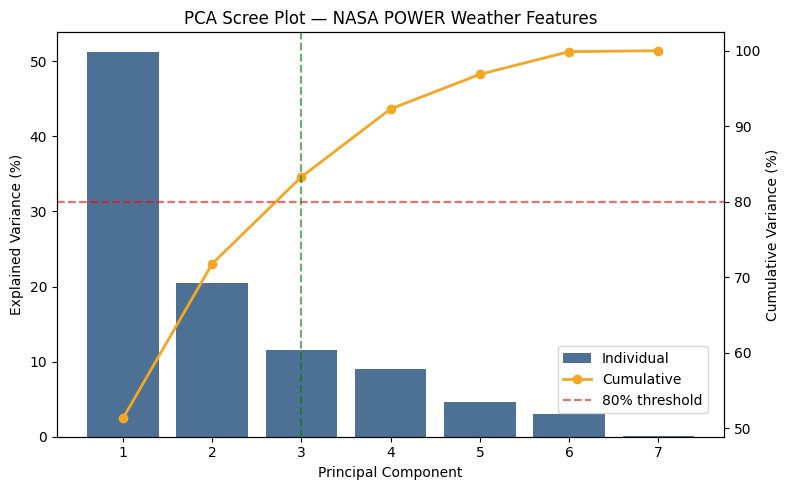

In [353]:
# -- STEP 1: Select numeric features -----------
pca_cols = ["T2M", "RH2M", "PS", "WS2M", "CLOUD_AMT",
            "ALLSKY_SFC_SW_DWN", "T2MDEW"]
pca_data = df[pca_cols].dropna()

# -- STEP 2: Scale (MANDATORY before PCA) ------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

# -- STEP 3: PCA — all components first --------
pca = PCA()
pca.fit(X_scaled)
 
ev = pca.explained_variance_ratio_
cum = np.cumsum(ev)
 
for i, (e, c) in enumerate(zip(ev, cum)):
    print(f"PC{i+1}: {e*100:.1f}%  (cumulative: {c*100:.1f}%)")

# -- STEP 4: Choose n_components for 80% -------
n80 = np.argmax(cum >= 0.80) + 1
print(f"\n{n80} components explain {cum[n80-1]*100:.1f}% of variance")

fig, ax1 = plt.subplots(figsize=(8, 5))
comps = range(1, len(ev) + 1)
ax1.bar(comps, ev * 100, color="#1F4E79", alpha=0.8, label="Individual")
ax2 = ax1.twinx()
ax2.plot(comps, cum * 100, "o-", color="#F5A623", lw=2, label="Cumulative")
ax2.axhline(80, color="red", ls="--", alpha=0.6, label="80% threshold")
ax2.axvline(n80, color="green", ls="--", alpha=0.6)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
ax2.set_ylabel("Cumulative Variance (%)")
plt.title("PCA Scree Plot — NASA POWER Weather Features")
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.savefig("pca_scree_plot.png", dpi=150)
plt.show()

In [354]:
df = df.drop(columns=["date", "Station"])
df.to_csv(r"Data\Processed\Processed.csv", index=False)